In [1]:
import seaborn as sns
import pandas as pd
import tabula
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# fetch the latest updated data
!curl https://files.floridalottery.com/exptkt/pb.pdf -o pb.pdf

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 727.1k 100 727.1k   0      0  1.27M      0                              0


# Data cleaning and sanitation

In [3]:
# ignore first page ==> additional content creates a parsing problems
df_lst_raw = tabula.read_pdf("pb.pdf", pages="2-90")

Failed to import jpype dependencies. Fallback to subprocess.
No module named 'jpype'


In [4]:
l = len(df_lst_raw)
print(l)

178


Why are there 178 elements instad of just 89?

In [5]:
df_lst_raw[0].head()

,Draw Date,Winning Numbers,Game,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,7/11/26,8,10,14,45,59,PB 5,X2,POWERBALL
1,7/11/26,5,7,17,26,28,PB 5,NaN,POWERBALL DP
2,7/8/26,12,29,37,43,55,PB 18,X4,POWERBALL
3,7/8/26,6,27,33,44,69,PB 23,NaN,POWERBALL DP
4,7/6/26,17,44,63,66,67,PB 4,X2,POWERBALL


In [6]:
df_lst_raw[1]

,Pages2/91


Thats it! `tabula` is reading the page numbers as separate table. Those can be easily excluded by filtering out using the column name

In [7]:
df = df_lst_raw[0]
for _df in  df_lst_raw[2:]:
    if not any("Pages" in c for c in _df.columns):
        df = pd.concat([df, _df], axis=0, ignore_index=True)

In [8]:
df.head()

,Draw Date,Winning Numbers,Game,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,7/11/26,8,10,14,45,59,PB 5,X2,POWERBALL
1,7/11/26,5,7,17,26,28,PB 5,NaN,POWERBALL DP
2,7/8/26,12,29,37,43,55,PB 18,X4,POWERBALL
3,7/8/26,6,27,33,44,69,PB 23,NaN,POWERBALL DP
4,7/6/26,17,44,63,66,67,PB 4,X2,POWERBALL


The column names are all messed up, lets fix them.

In [9]:
df = df.rename(columns = {"Draw Date": "date",
                     "Winning Numbers": "white_ball_1",
                     "Game": "white_ball_2",
                     "Unnamed: 0": "white_ball_3",
                     "Unnamed: 1": "white_ball_4",
                     "Unnamed: 2": "white_ball_5",
                     "Unnamed: 3": "red_ball", # Power Ball number
                     "Unnamed: 4": "pp_mult",  # Power Play multiplier
                     "Unnamed: 5": "game"})

In [10]:
df.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,7/11/26,8,10,14,45,59,PB 5,X2,POWERBALL
1,7/11/26,5,7,17,26,28,PB 5,NaN,POWERBALL DP
2,7/8/26,12,29,37,43,55,PB 18,X4,POWERBALL
3,7/8/26,6,27,33,44,69,PB 23,NaN,POWERBALL DP
4,7/6/26,17,44,63,66,67,PB 4,X2,POWERBALL


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          2848 non-null   str  
 1   white_ball_1  2848 non-null   int64
 2   white_ball_2  2848 non-null   int64
 3   white_ball_3  2848 non-null   int64
 4   white_ball_4  2848 non-null   int64
 5   white_ball_5  2848 non-null   int64
 6   red_ball      2848 non-null   str  
 7   pp_mult       2083 non-null   str  
 8   game          2848 non-null   str  
dtypes: int64(5), str(4)
memory usage: 200.4 KB


Much better, but there's still some problemns. The `pb` and `pp` columns are `str` type and need to be `int`. Before they can be casted, the additinal characters (PB, X) must be removed from each column. The date is also a `str`, so needs to be converted to a date type if date operation are needed.

In [12]:
df['red_ball'] = df['red_ball'].str.replace('PB ', '', regex=False)
df['pp_mult'] = df['pp_mult'].str.replace('X', '', regex=False)

In [13]:
df['red_ball'] = df['red_ball'].astype(int)
# the astype method cannot be used directly with the pp column since it contain NaN strings which cannot be
# casted to int directly. Instead we use the to_numeric method with the "coerce" option which forces the casting
# on the valid elements but asigns NaN to the unvalid ones.
df['pp_mult'] = pd.to_numeric(df['pp_mult'], errors="coerce").astype("Int64")
df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_3940994/528970629.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [14]:
df.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,2026-07-11,8,10,14,45,59,5,2,POWERBALL
1,2026-07-11,5,7,17,26,28,5,<NA>,POWERBALL DP
2,2026-07-08,12,29,37,43,55,18,4,POWERBALL
3,2026-07-08,6,27,33,44,69,23,<NA>,POWERBALL DP
4,2026-07-06,17,44,63,66,67,4,2,POWERBALL


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2848 non-null   datetime64[us]
 1   white_ball_1  2848 non-null   int64         
 2   white_ball_2  2848 non-null   int64         
 3   white_ball_3  2848 non-null   int64         
 4   white_ball_4  2848 non-null   int64         
 5   white_ball_5  2848 non-null   int64         
 6   red_ball      2848 non-null   int64         
 7   pp_mult       2083 non-null   Int64         
 8   game          2848 non-null   str           
dtypes: Int64(1), datetime64[us](1), int64(6), str(1)
memory usage: 203.2 KB


Data looks good now, so we can go ahead and save the cleaned version to disk.

In [16]:
df.to_csv("powerball_numbers_cleaned.csv", index=False)

## Consistency Checks

In the powerball drawing, the number of the 5 white balls should be in the range `[1-69]`. The red ball (power ball) numbers should be in the range `[1-26]`

In [18]:
assert df[[f"white_ball_{x}" for x in range(1,6)]].min(axis=None) >= 1,  "White ball numbers out of range!"
assert df[[f"white_ball_{x}" for x in range(1,6)]].max(axis=None) <= 69, "White ball numbers out of range!"

In [19]:
assert df["red_ball"].min(axis=None) >= 1,  "Red (Power) ball numbers out of range!"
assert df["red_ball"].max(axis=None) <= 26, "Red (Power) ball numbers out of range!"

AssertionError: Red (Power) ball numbers out of range!

In [20]:
df["red_ball"].max(axis=None)

np.int64(39)

But why? Turns out there have been several versions of the powerball with different ball numbering ranges. Seven versions in total to be precise. The availbale data starts on January 7, 2009 and cover the last three versions: versions 5, 6 and 7 (the current version).

|version  |  start date  | end date   | white ball range  | red ball range |
|---------|------------- |------------|-------------------|-----------------
|5        | 2009-01-07   | 2012-01-14 |  1-59             | 1-39           |
|6        | 2012-01-18   | 2015-10-03 |  1-59             | 1-35           |
|7        | 2015-10-07   | present    |  1-69             | 1-26           |

The dataset must be split into these cases to avoid skewing the statistical results

In [21]:
df_v5 = df[ (df["date"] >= "2009-01-07") & (df["date"] <= "2012-01-14")]
assert df_v5["red_ball"].max(axis=None) == 39, "Power ball numbers out of range!"
df_v5.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
2532,2012-01-14,10,30,36,38,41,1,5,POWERBALL
2533,2012-01-11,5,19,29,45,47,25,2,POWERBALL
2534,2012-01-07,3,21,24,38,39,24,5,POWERBALL
2535,2012-01-04,21,35,46,47,50,2,4,POWERBALL
2536,2011-12-31,5,23,25,28,40,34,4,POWERBALL


In [22]:
df_v6 = df[ (df["date"] >= "2012-01-18") & (df["date"] <= "2015-10-03")]
assert df_v6["red_ball"].max(axis=None) == 35, "Power ball numbers out of range!"
df_v6.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
2144,2015-10-03,6,26,33,44,46,4,2,POWERBALL
2145,2015-09-30,21,39,40,55,59,17,3,POWERBALL
2146,2015-09-26,23,31,42,50,57,5,3,POWERBALL
2147,2015-09-23,8,29,41,51,58,5,2,POWERBALL
2148,2015-09-19,12,17,26,43,48,24,2,POWERBALL


In [23]:
df_v7 = df[df["date"] >= "2015-10-07"]
assert df_v7["red_ball"].max(axis=None) == 26, "Power ball numbers out of range!"
df_v7.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,2026-07-11,8,10,14,45,59,5,2,POWERBALL
1,2026-07-11,5,7,17,26,28,5,<NA>,POWERBALL DP
2,2026-07-08,12,29,37,43,55,18,4,POWERBALL
3,2026-07-08,6,27,33,44,69,23,<NA>,POWERBALL DP
4,2026-07-06,17,44,63,66,67,4,2,POWERBALL


In [24]:
df_v7["game"].unique().tolist()

['POWERBALL', 'POWERBALL DP']

Note that `v7` has two different values in the `game` column: `POWERBALL` and `POWERBALL DP`. The former is the plain old powerball draw while the latter refers to the douple play (hence DP) draw. The double play draw was introduced in August 23, 2021. Note that this falls within version 7 so thats why `POWERBALL DP` is missing from the other dataframes. Lets confirm this to make sure we split the data correctly.

In [25]:
print("Unique games in v5:", df_v5["game"].unique().tolist())
print("Unique games in v6:",df_v6["game"].unique().tolist())
print("Earliest date of POWERBALL DP in v7:", df_v7[df_v7["game"] == "POWERBALL DP"]["date"].min())

Unique games in v5: ['POWERBALL']
Unique games in v6: ['POWERBALL']
Earliest date of POWERBALL DP in v7: 2021-08-23 00:00:00


The earliest occurence of a `POWERBALL DP` value in the `game` column of `v7` matches our expectation of August 23, 2021. To avoid mixing things up, lets further split the `v7` data based on the game column.

In [26]:
df_v7_pb = df_v7[ df_v7["game"] == "POWERBALL" ]
df_v7_dp = df_v7[ df_v7["game"] == "POWERBALL DP" ]

In [27]:
df_v7_pb.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,2026-07-11,8,10,14,45,59,5,2,POWERBALL
2,2026-07-08,12,29,37,43,55,18,4,POWERBALL
4,2026-07-06,17,44,63,66,67,4,2,POWERBALL
6,2026-07-04,17,38,46,50,69,20,2,POWERBALL
8,2026-07-01,2,6,26,39,68,6,2,POWERBALL


In [28]:
df_v7_dp.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
1,2026-07-11,5,7,17,26,28,5,<NA>,POWERBALL DP
3,2026-07-08,6,27,33,44,69,23,<NA>,POWERBALL DP
5,2026-07-06,22,25,27,47,50,21,<NA>,POWERBALL DP
7,2026-07-04,4,19,24,25,41,9,<NA>,POWERBALL DP
9,2026-07-01,10,20,30,60,64,7,<NA>,POWERBALL DP


This concludes the data preparation step.

# Statistical Analysis

In [29]:
white_ball_cols = ["white_ball_1","white_ball_2", "white_ball_3", "white_ball_4", "white_ball_5"]

<Axes: ylabel='Count'>

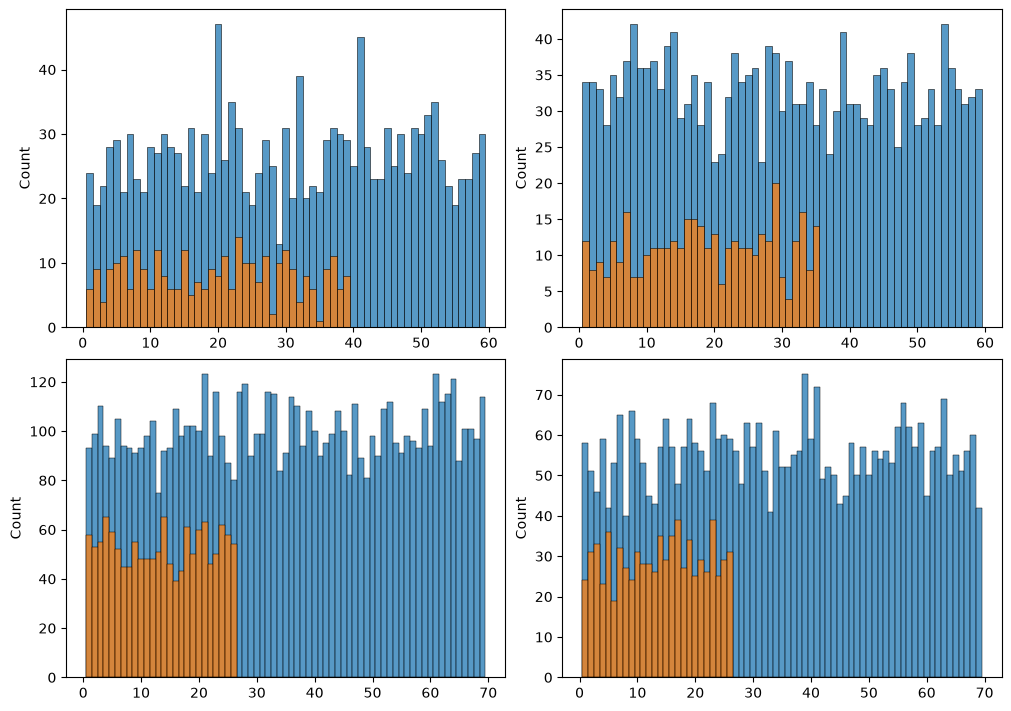

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), layout='constrained')#, sharex='all', sharey='all')
sns.histplot(df_v5[white_ball_cols].to_numpy().flatten(), stat="count", discrete=True, ax = axes[0,0])
sns.histplot(df_v5["red_ball"].to_numpy().flatten(),stat="count", discrete=True, ax = axes[0,0])

sns.histplot(df_v6[white_ball_cols].to_numpy().flatten(), stat="count", discrete=True, ax = axes[0,1])
sns.histplot(df_v6["red_ball"].to_numpy().flatten(),stat="count", discrete=True, ax = axes[0,1])

sns.histplot(df_v7_pb[white_ball_cols].to_numpy().flatten(), stat="count", discrete=True, ax = axes[1,0])
sns.histplot(df_v7_pb["red_ball"].to_numpy().flatten(), stat="count", discrete=True, ax = axes[1,0])

sns.histplot(df_v7_dp[white_ball_cols].to_numpy().flatten(), stat="count", discrete=True, ax = axes[1,1])
sns.histplot(df_v7_dp["red_ball"].to_numpy().flatten(), stat="count", discrete=True, ax = axes[1,1])

In [ ]:
We can see

In [31]:
# ax = sns.histplot({"v5": df_v5[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten(),
#                    # "v6": df_v6[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten(),
#                    # "v7": df_v7[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten()},
#                    # discrete=True)

In [32]:
# tmp = pd.Series(df_v5[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten()).value_counts()

In [ ]:
tmp[20]

In [ ]:
tmp.index